# Optimization for Machine Learning: Computer Lab 1



## 2. Preprocessing the data

Here, we load the data, standardize it, and set it in the appropriate shape for performing linear regression. You do not need to complete anything in this section; however it is important that you understand what the code is doing. See the pdf instructions for more details.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Loading data
data_matrix_train, COP_train, data_matrix_test, COP_test, names = np.load('data_center_data_matrix.npy', allow_pickle=True)

In [9]:
# centering and normalizing the matrix
matrix_mean = np.mean(data_matrix_train, axis=0)
M = data_matrix_train - matrix_mean

matrix_std = np.std(M, axis=0)
M = M / matrix_std

In [10]:
M.shape

(722, 892)

In [11]:
M.T.shape

(892, 722)

In [12]:
COP_train[:,3].shape

(722,)

In [13]:
(M.T * COP_train[:,3]).T.shape

(722, 892)

In [14]:
# Building the corresponding matrices A,b for linear regression
A = np.hstack([M, np.ones((M.shape[0],1)), -(M.T * COP_train[:,3]).T])
b = COP_train[:,3]

# Building the same matrices for the test set
M_test = (data_matrix_test - matrix_mean) / matrix_std
A_test = np.hstack([M_test, np.ones((M_test.shape[0],1)), -(M_test.T * COP_test[:,3]).T])
b_test = COP_test[:,3]

d = A.shape[1]

## 3. Ordinary least squares

We now wish to solve the problem
$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2
$$

##### Question 3.1

Show that if $Aw = b$, then $ y(t) = \frac {w_1^T\tilde{x}(t) + w_0}{w_2^T\tilde{x}(t) + 1}$.

If $Aw = b$, then:
\begin{equation}
\tilde{x}(t)^Tw_1 + w_0 = y(t)(1 + \tilde{x}(t)^Tw2)
\end{equation}
Isolate $y(t)$:
\begin{equation}
y(t) = \frac {w_1^T\tilde{x}(t) + w_0}{w_2^T\tilde{x}(t) + 1}
\end{equation}

##### Question 3.2 and 3.3

In [15]:
## Question 3.2: solve with the numpy least squares solver

# COMPLETE HERE
w_least_squares = np.linalg.lstsq(A, b)[0]

In [16]:
## Question 3.3

# COMPLETE HERE
test_error = np.mean(np.square(A_test @ w_least_squares - b_test))
print("Test error for least squares solution : ", test_error)

Test error for least squares solution :  780.8984793523127


### Adding $\ell_2$ regularization

In order to improve the performance on the test set, we add $\ell_2$ regularization:

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \frac \lambda 2 \|w\|_2^2
$$

##### Question 3.4

Calculate the gradient of $f_1$:

\begin{equation}
∇f_1 = A^T(Aw - b) + λw
\end{equation}


The function $f_1$ is a linear combination of $A^T(Aw - b)$ and $λw$. Both are linear and, therefore convex. Hence, $f_1$ is also convex.

For the Lipschitz gradient we can write $\|∇f_1(w) - ∇f_1(z)\|$ as:

\begin{equation}
\|A^T(Aw - b) + λw - A^T(Az - b) + λz\| = \\= \|A^TAw + λw - A^TAz - λz - A^Tb + A^Tb\|\\
= \|A^TA(w - z) + λI(w - z)\| \\
= \|(A^TA + λI)(w - z)\| \\
\end{equation}

We know that

\begin{equation}
= \|(A^TA + λI)(w - z)\| \le \|(A^TA + λI)\|\|(w - z)\|   \\
\end{equation}

We conclude that $L = \|(A^TA + λI)\|$.

In [17]:
lambda_l2 = 1e4

##### Question 3.5

In [18]:
# Question 3.5

def f(w):
    # COMPLETE HERE
    return 0.5*np.sum(np.square(A@w - b)) + 0.5*lambda_l2*np.sum(np.square(w))


def grad_f(w):
    # COMPLETE HERE
    return A.T@(A@w - b) + lambda_l2*w

def gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        w = w - gamma*grad_f(w)
        f_values.append(f(w))
        grad_norm = np.linalg.norm(grad_f(w))
        gradient_norms.append(grad_norm)
        if grad_norm < 1:
          print(f"Achieved convergence at iteration {t}")
          break

    return w, f_values, gradient_norms

Lipschitz constant

For finding the appropriate step size range, we need to estimate the Lipschitz constant of the gradient. Then we will use step = 1/L, because this way we will have guaratee of convergence.[texto do link](https://)

In [19]:
# COMPLETE HERE
L = np.linalg.norm(A.T@A + lambda_l2*np.identity(A.shape[1]), ord=2)

In [20]:
w0 = np.zeros(d)
step_size = 1/L
max_iter = 4500

w_GD, f_values_GD, gradient_norms_GD = gradient_descent(f, grad_f, w0, step_size, max_iter)

Achieved convergence at iteration 2339


2339 iterations were needed to get $w_k$ such that $\| ∇f(w_k\| \le 1 $.

We now compute the evolution of function values and gradient norm.

Text(0, 0.5, 'Function values')

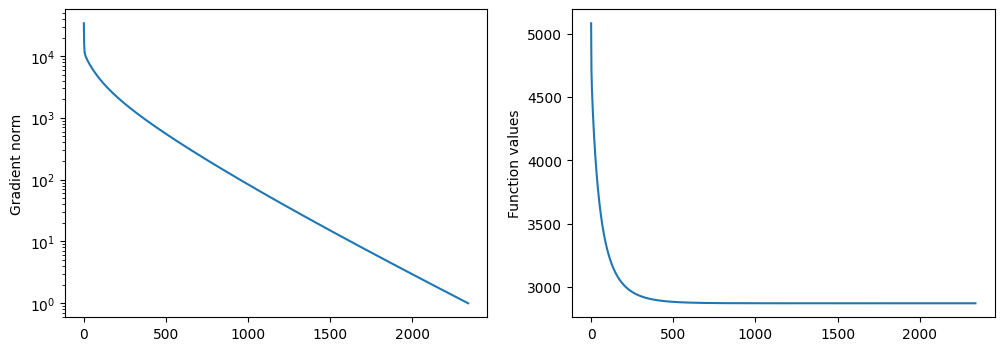

In [21]:
# let us plot the result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")

axes[1].plot(f_values_GD)
axes[1].set_ylabel("Function values")

In [22]:
print(gradient_norms_GD[-1])

0.9988674836038234


##### Question 3.6

In [23]:
# Question 3.6

# COMPLETE HERE
test_error_l2 = np.mean(np.square(A_test @ w_GD - b_test))
print("Test error for l2 penalized solution : ", test_error_l2)

Test error for l2 penalized solution :  61.522725283027825


What do you observe?

Notice that the test error with regularization (61.523) is really smaller than without it (78.898), which suggests that regularization was indeed necessary. Hence, regularization improved generalization.

We can observe that both the gradient norm and function values obtain a huge decrease at first. However, the gradient replace this exponential decay for a linear one while the function values estabilize, decaying insignificantly after few iterations.



### Line search

Question 3.7

The step size given by theory is can be too conservative in practice. We propose to implement a backtracking line search procedure to find a better one automatically.


In [24]:
# Question 3.7

def gradient_descent_line_search(f, grad_f, w0, gamma_0, max_iter):
    w = w0.copy()

    # initial step size
    gamma = gamma_0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        gamma_plus = gamma
        current_grad_f_val = grad_f(w) # Store the gradient value in a new variable

        while True:
          # compute xk_plus
          w_plus = w - gamma_plus*current_grad_f_val
          if f(w_plus) <= f(w) + current_grad_f_val.T @ (w_plus-w) + (1/(2*gamma_plus))*np.sum(np.square(w_plus-w)):
            w = w_plus
            gamma = gamma_plus*2
            break
          else:
            gamma_plus = gamma_plus/2

        f_values.append(f(w))
        current_grad_f_val = grad_f(w) # Update the gradient value for the new w
        grad_norm = np.linalg.norm(current_grad_f_val)
        gradient_norms.append(grad_norm)

        if grad_norm < 1:
          print(f"Converged at iteration {t} with grad_norm = {grad_norm}")
          break

    return w, f_values, gradient_norms

In [44]:
# COMPLETE HERE
w0 = np.zeros(d)
step_size = np.float128(1)
max_iter = 5000

w_GD_LS, f_values_GD_LS, gradient_norms_GD_LS = gradient_descent_line_search(f, grad_f, w0, step_size, max_iter)

Converged at iteration 890 with grad_norm = 0.9961994094014839


Text(0, 0.5, 'Function values with line search')

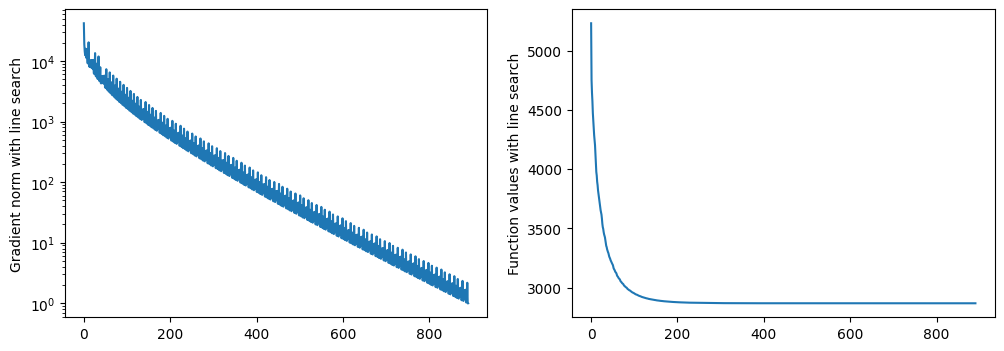

In [45]:
# let us plot the result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD_LS)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm with line search")

axes[1].plot(f_values_GD_LS)
axes[1].set_ylabel("Function values with line search")

Notice that line search algorithm took 20 times less iterations to converge,
showing evidences of the adaptive method being way faster than the fixed step size technique.

### Accelerated gradient method

Question 3.8

For a faster algorithm, we could implement accelerated gradient descent.

In [27]:
# Question 3.8 (optional)

def accelerated_gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        beta = (t+1)/(t+4)
        w_aux = w - gamma*grad_f(w)
        w = w_aux + beta*(w_aux - w)

        f_values.append(f(w))
        grad_norm = np.linalg.norm(grad_f(w))
        gradient_norms.append(grad_norm)
        if grad_norm < 1:
          print(f"Achieved convergence at iteration {t}")
          break

    return w, f_values, gradient_norms


In [28]:
# COMPLETE HERE
w0 = np.zeros(d)
step_size = 1/L
max_iter = 5000

w_AGD, f_values_AGD, gradient_norms_AGD = accelerated_gradient_descent(f, grad_f, w0, step_size, max_iter)

Achieved convergence at iteration 1176


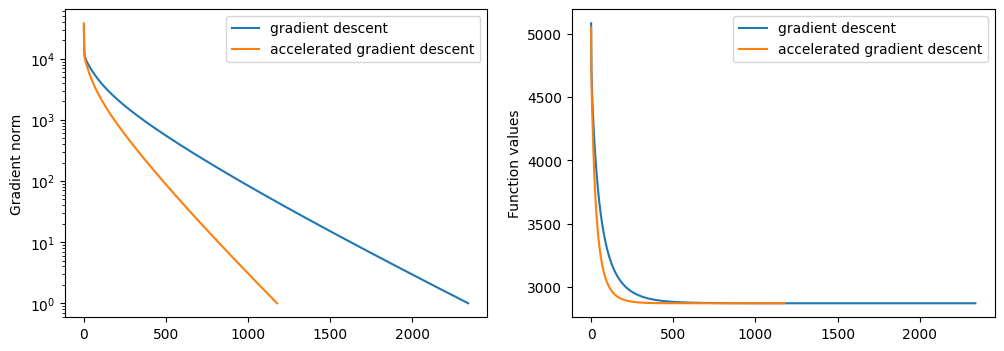

In [29]:
# let us plot the result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD, label = "gradient descent")
axes[0].plot(gradient_norms_AGD, label = "accelerated gradient descent")
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")
axes[0].legend()

axes[1].plot(f_values_GD, label = "gradient descent")
axes[1].plot(f_values_AGD, label = "accelerated gradient descent")
axes[1].set_ylabel("Function values")
axes[1].legend()

What do you observe regarding the convergence speed ?

It is clear that the accelerated method converges in much less iterations than the traditional method. This was already expected as it was seen in course that the accelerated method improves the rate of GD from O(1/k) to O(1/k²).

## 4. Adding $\ell_1$ regularization (Lasso)

We now solve

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \lambda \|w\|_1
$$

#### Question 4.1
Let

\begin{equation}
F_{2}=\frac 12 \|Aw - b\|_2^2 + \lambda\|w\|_1
\end{equation}

We can write
\begin{equation}F_{2} = f_{2} + g_{2} \end{equation}
where
\begin{equation} f_{2} = \frac 12 \|Aw - b\|_2^2 \end{equation}
and
\begin{equation} g_{2} = \lambda\|w\|_1 \end{equation}

The formula for $\operatorname{prox}_{g_2}$:

\begin{equation}
\operatorname{prox}_{g_2} (x) = \arg\min_{y \in \mathbb{R}^n} g_2(y) + \frac 12\| y - x\|^2
\end{equation}

\begin{equation}
= S (\frac x{γλ})
\end{equation}

We can calculate the gradient of $f$:
\begin{equation}
  ∇f(x_k) = A^T (Ax_k - b)
\end{equation}

For stopping criterion, I will use $ \frac {\|x_{k+1} - x_k\|}{max(1.0, \|w\|)}$. This way, we can stop whenever the updates are not so meaningful anymore.

In [30]:
lambda_l1 = 1e3

## Question 4.2

# Define the objective function f (full objective including L1) for the training split
def f_lasso(w):
    return 0.5 * np.sum(np.square(A @ w - b)) + lambda_l1 * np.sum(np.abs(w))

# Define the gradient of the smooth part of the objective for the training split
def grad_f_lasso(w):
    return A.T @ (A @ w - b)

def prox_l1(x, mu = 1.):
    """compute the proximal operator of mu * |x|_1
    """
    # COMPLETE HERE

    return np.sign(x) * np.maximum(0.0, np.abs(x)-mu)


def proximal_gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        mu = gamma * lambda_l1
        w_new = prox_l1(w - gamma*grad_f(w), mu)
        change = np.linalg.norm(w_new - w) / max(1.0, np.linalg.norm(w))
        w = w_new

        grad_norm = np.linalg.norm(grad_f(w))
        gradient_norms.append(grad_norm)
        f_values.append(f(w))
        if (change < 0.0009): #stopping criterion
          print(f"Converged at iteration {t} with change {change}")
          break

    return w, f_values, gradient_norms

In [31]:
# COMPLETE HERE
L = np.linalg.norm(A.T @ A, ord = 2)
w0 = np.zeros(d)
step_size = 1/L
max_iter = 5000

w_PGD, f_values_PGD, gradient_norms_PGD = proximal_gradient_descent(f_lasso, grad_f_lasso, w0, step_size, max_iter)

Converged at iteration 89 with change 0.0008992818088936016


In [32]:
# Question 4.3

test_error_l1 = np.mean(np.square(A_test @ w_PGD - b_test))
print("Test error for l1 penalized solution : ", test_error_l1)

Test error for l1 penalized solution :  40.58929589639442


Compare with the previous test errors. What do you observe?

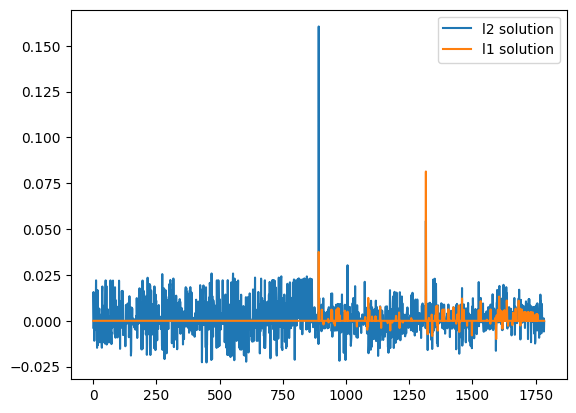

In [33]:
# Let us examine the solution
plt.plot(w_GD, label = "l2 solution")
plt.plot(w_PGD, label = "l1 solution")
plt.legend()

What do you observe regarding the difference in **structure** of the two solutions?

In ridge solution, we observe that the coefficients are small and  close to zero, but none of them is exactly zero.

By the other hand, in lasso, coefficients are sparse, various of them are zero and the features that remain active have higher values.

## [BONUS] Tuning the penalization parameter

How to find the best solution among all those that were comptued? How to choose the penalization parameter $\lambda$?

The best way is to do a grid search through different values of lambda.

In [34]:
# Your method here...

# Split samples
n_samples = A.shape[0]
train_size = int(0.85 * n_samples)
A_train_split = A[:train_size]
b_train_split = b[:train_size]
A_val_split = A[train_size:]
b_val_split = b[train_size:]

# Calculate constants
L_grid = np.linalg.norm(A_train_split.T @ A_train_split, ord=2)
step_size_grid = 1 / L_grid
w0_grid = np.zeros(d)
max_iter_grid = 5000

lambda_l1_0 = 1e9
a = 0.1
lambda_values = [lambda_l1_0*(a**k) for k in range(0,9)]
w_values = []
validation_errors = []

In [35]:
# Define the gradient of the smooth part of the objective for the training split
def grad_f_grid_lasso(w):
    return A_train_split.T @ (A_train_split @ w - b_train_split)

# pgd for grid search
def pgd_grid(grad_f, w0, gamma, lambda_l1_grid, max_iter):
    w = w0.copy()

    for t in range(max_iter):
        mu = gamma * lambda_l1_grid
        w_new = prox_l1(w - gamma*grad_f(w), mu)
        change = np.linalg.norm(w_new - w) / max(1.0, np.linalg.norm(w))
        w = w_new

        if (change < 0.0009): #stopping criterion
          print(f"Converged at iteration {t} with change {change}")
          break

    return w

In [36]:
#Execute grid search
for current_lambda_val in lambda_values:

  # Run proximal gradient descent
  w_pgd_lambda = pgd_grid(
      grad_f=grad_f_grid_lasso,
      w0=w0_grid,
      gamma=step_size_grid,
      lambda_l1_grid=current_lambda_val,
      max_iter=max_iter_grid
  )

  # Calculate validation error
  val_error = np.mean(np.square(A_val_split @ w_pgd_lambda - b_val_split))
  validation_errors.append(val_error)
  w_values.append(w_pgd_lambda)

print("\nFinished grid search. Validation errors per lambda value:")
for l, err in zip(lambda_values, validation_errors):
  print(f"Lambda: {l}, Error: {err}")



Converged at iteration 0 with change 0.0
Converged at iteration 0 with change 0.0
Converged at iteration 0 with change 0.0
Converged at iteration 0 with change 0.0
Converged at iteration 0 with change 0.0
Converged at iteration 0 with change 0.0
Converged at iteration 144 with change 0.0008992672805459988
Converged at iteration 179 with change 0.0008980683225453833
Converged at iteration 174 with change 0.0008960625859930735

Finished grid search. Validation errors per lambda value:
Lambda: 1000000000.0, Error: 30.60005908244152
Lambda: 100000000.0, Error: 30.60005908244152
Lambda: 10000000.000000002, Error: 30.60005908244152
Lambda: 1000000.0000000002, Error: 30.60005908244152
Lambda: 100000.00000000001, Error: 30.60005908244152
Lambda: 10000.000000000002, Error: 30.60005908244152
Lambda: 1000.0000000000003, Error: 134.0482115759392
Lambda: 100.00000000000003, Error: 392.22884523021594
Lambda: 10.000000000000005, Error: 432.0332102473617


In [37]:
optimal_lambda_idx = np.argmin(validation_errors)
best_lambda = lambda_values[optimal_lambda_idx]
min_val_error = validation_errors[optimal_lambda_idx]
best_w = w_values[optimal_lambda_idx]

print(f"Optimal Lambda: {best_lambda}")
print(f"Minimum Validation Error: {min_val_error}")

Optimal Lambda: 1000000000.0
Minimum Validation Error: 30.60005908244152


In [38]:
#Test error
test_error_grid_search = np.mean(np.square(A_test @ best_w - b_test))
print(f"Test error: {test_error_grid_search}")

Test error: 79.82867294741006


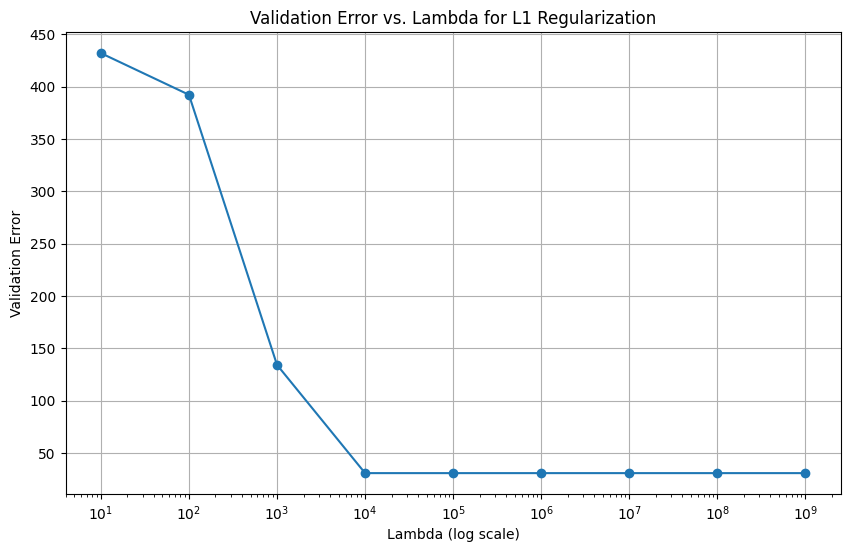

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, validation_errors, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Validation Error')
plt.title('Validation Error vs. Lambda for L1 Regularization')
plt.grid(True)
plt.show()

It is curious to notice that the test error of our grid search method is bigger than the test error from the proximal method with a fixed lambda. That probably happens due to the insuficient size of validation dataset, which leads to bad evaluationg of our lambdas.